# 06 — Investigação de Erros e Candidatos a Famílias

## Objetivo

Investigar falsos positivos, falsos negativos e candidatos iniciais de agrupamento de alarmes,
sem alterar a definição de limpeza, sequência, janelas, target ou split temporal do baseline.

As perguntas principais são:

1. quais `TAGs` e `Id_Alarme` concentram falsos positivos de alta probabilidade;
2. quais `TAGs`, tipos de equipamento e `Id_Alarme` concentram falsos negativos;
3. qual é a evidência específica para escavadeiras;
4. quais descrições de alarme sugerem candidatos auditáveis de `conceito_alarme`;
5. quais agrupamentos merecem teste no próximo modelo.

## Limites

Esta auditoria continua prevendo novos episódios da flag `Is_Dont_Go`, não falhas confirmadas. Uma
janela sem evento continua significando apenas ausência de evento registrado, não operação saudável
observada.

O mapeamento de famílias neste notebook é **candidato**, não definitivo. Ele deve nascer dos erros
observados e só deve virar feature depois de validação em modelo posterior.

In [1]:
from pathlib import Path
import re
import time
import unicodedata

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    average_precision_score, balanced_accuracy_score, confusion_matrix,
    f1_score, fbeta_score, precision_score, recall_score, roc_auc_score,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 250)
pd.set_option("display.max_rows", 200)

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
BASE = ROOT / "data" / "raw" / "Base"
TEL_GLOB = str(BASE / "datasets" / "telemetria" / "telemetry_*.parquet")

SEQUENCE_GAP_SECONDS = 60
OBSERVATION_HOURS = 8
HORIZON_HOURS = 8
TOP_ALARM_IDS = 200
MISSING_DAY = pd.Timestamp("2025-05-31")
LOOP_TAG = "PE3798"
LOOP_DAY = pd.Timestamp("2025-06-29")
LOOP_ALARM_IDS = (1241582851, 1241582848)

con = duckdb.connect()
con.execute("SET threads=4")
con.execute("SET preserve_insertion_order=false")
con.execute(f"CREATE OR REPLACE VIEW tel AS SELECT * FROM read_parquet('{TEL_GLOB}', union_by_name=true)")

def query(sql):
    return con.sql(sql).df()

print(f"Raiz do projeto: {ROOT}")
print("Premissas reproduzidas do notebook 03:")
print(f"- sequência: {SEQUENCE_GAP_SECONDS}s")
print(f"- observação/horizonte: {OBSERVATION_HOURS}h/{HORIZON_HOURS}h")
print(f"- IDs no vocabulário: {TOP_ALARM_IDS}")

Raiz do projeto: /home/f_szekut/projects/vale_correct
Premissas reproduzidas do notebook 03:
- sequência: 60s
- observação/horizonte: 8h/8h
- IDs no vocabulário: 200


## 1. Reconstituição controlada da base do baseline

Esta seção recompõe a mesma camada analítica do notebook 03. A duplicação aqui é intencional:
mantém este notebook executável de forma independente e permite auditar o baseline sem depender de
estado temporário em memória.

As regras reproduzidas são:

- expurgo apenas do loop localizado da `PE3798` em `29/06/2025`;
- deduplicação exata ignorando somente `Id_Eventos_Telemetria`;
- formação de sequências por `TAG + Id_Alarme` com gap maior que 60 segundos;
- janelas calendarizadas de 8 horas;
- invalidação da lacuna global de `31/05/2025`;
- split temporal sem aleatoriedade.

In [2]:
start = time.time()

con.execute(
    f'''
    CREATE OR REPLACE TEMP TABLE analytic_events AS
    SELECT
        min(Id_Eventos_Telemetria) AS Id_Eventos_Telemetria_referencia,
        Data_Evento, Inicio_Turno, Fim_Turno, Dia, Localidade, TAG, Tag_Frota, Tipo,
        Nome_Operador_Anon, Matricula_Operador_Hash, Id_Alarme, Alarme,
        Id_Criticidade, Criticidade, Valor, Classe, Is_Dont_Go,
        count(*) AS ids_evento_no_grupo
    FROM tel
    WHERE NOT (
        TAG = '{LOOP_TAG}'
        AND CAST(Data_Evento AS DATE) = DATE '{LOOP_DAY.date()}'
        AND Id_Alarme IN {LOOP_ALARM_IDS}
    )
    GROUP BY
        Data_Evento, Inicio_Turno, Fim_Turno, Dia, Localidade, TAG, Tag_Frota, Tipo,
        Nome_Operador_Anon, Matricula_Operador_Hash, Id_Alarme, Alarme,
        Id_Criticidade, Criticidade, Valor, Classe, Is_Dont_Go
    '''
)

con.execute(
    f'''
    CREATE OR REPLACE TEMP TABLE alarm_sequences AS
    WITH ordered AS (
        SELECT *,
               lag(Data_Evento) OVER (
                   PARTITION BY TAG, Id_Alarme ORDER BY Data_Evento, Id_Eventos_Telemetria_referencia
               ) AS evento_anterior
        FROM analytic_events
    ), flagged AS (
        SELECT *,
               CASE
                   WHEN evento_anterior IS NULL THEN 1
                   WHEN date_diff('millisecond', evento_anterior, Data_Evento)
                        > {SEQUENCE_GAP_SECONDS * 1000} THEN 1
                   ELSE 0
               END AS nova_sequencia
        FROM ordered
    ), numbered AS (
        SELECT *,
               sum(nova_sequencia) OVER (
                   PARTITION BY TAG, Id_Alarme
                   ORDER BY Data_Evento, Id_Eventos_Telemetria_referencia
                   ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
               ) AS numero_sequencia
        FROM flagged
    )
    SELECT
        TAG, any_value(Tag_Frota) AS Tag_Frota, any_value(Tipo) AS Tipo,
        Id_Alarme, any_value(Alarme) AS Alarme,
        numero_sequencia,
        min(Data_Evento) AS inicio,
        max(Data_Evento) AS fim,
        date_diff('millisecond', min(Data_Evento), max(Data_Evento)) AS duracao_ms,
        count(*) AS registros_analiticos,
        sum(ids_evento_no_grupo) AS registros_brutos_representados,
        max(Is_Dont_Go) AS is_dont_go,
        max(CASE WHEN Id_Criticidade = 1 THEN 1 ELSE 0 END) AS possui_critico,
        max(CASE WHEN Classe = 'Activate' THEN 1 ELSE 0 END) AS possui_activate,
        max(CASE WHEN Classe = 'Inactive' THEN 1 ELSE 0 END) AS possui_inactive,
        max(CASE WHEN Classe IS NULL THEN 1 ELSE 0 END) AS possui_classe_nula
    FROM numbered
    GROUP BY TAG, Id_Alarme, numero_sequencia
    '''
)

rebuild_audit = query(
    '''
    SELECT
        (SELECT count(*) FROM analytic_events) AS registros_analiticos,
        (SELECT sum(ids_evento_no_grupo - 1) FROM analytic_events) AS duplicatas_retiradas,
        (SELECT sum(Is_Dont_Go) FROM analytic_events) AS linhas_dont_go,
        (SELECT count(*) FROM alarm_sequences) AS sequencias,
        (SELECT sum(is_dont_go) FROM alarm_sequences) AS sequencias_dont_go
    '''
)
rebuild_audit["tempo_s"] = round(time.time() - start, 1)
display(rebuild_audit)

,registros_analiticos,duplicatas_retiradas,linhas_dont_go,sequencias,sequencias_dont_go,tempo_s
0,35608094,265564.0,19941.0,4303625,14612.0,105.5


## 2. Janelas, features e modelo

O modelo abaixo é treinado com as mesmas features do notebook 03:

- agregados das sequências iniciadas nas 8 horas anteriores;
- contagens dos 200 `Id_Alarme` mais frequentes no treino;
- codificação cíclica de hora e dia da semana.

O teste continua isolado: junho não participa da seleção dos IDs, do treino nem da escolha de
threshold.

In [3]:
con.execute(
    '''
    CREATE OR REPLACE TEMP TABLE sequence_bins AS
    SELECT
        TAG,
        time_bucket(INTERVAL '8 hours', inicio) AS bin_start,
        count(*) AS sequencias_total,
        count(DISTINCT Id_Alarme) AS alarmes_distintos,
        sum(registros_analiticos) AS registros_analiticos,
        sum(registros_brutos_representados) AS registros_brutos_representados,
        avg(duracao_ms) AS duracao_media_ms,
        max(duracao_ms) AS duracao_max_ms,
        max(registros_analiticos) AS maior_sequencia_registros,
        sum(possui_critico) AS sequencias_com_critico,
        sum(possui_activate) AS sequencias_com_activate,
        sum(possui_inactive) AS sequencias_com_inactive,
        sum(possui_classe_nula) AS sequencias_com_classe_nula,
        sum(is_dont_go) AS episodios_dont_go
    FROM alarm_sequences
    GROUP BY 1, 2
    '''
)

con.execute(
    '''
    CREATE OR REPLACE TEMP TABLE sample_grid AS
    WITH tags AS (
        SELECT DISTINCT TAG FROM analytic_events
    ), feature_bins AS (
        SELECT * FROM generate_series(
            TIMESTAMP '2025-01-01 00:00:00',
            TIMESTAMP '2025-06-30 08:00:00',
            INTERVAL '8 hours'
        ) AS t(feature_start)
    )
    SELECT
        tags.TAG,
        feature_start,
        feature_start + INTERVAL '8 hours' AS prediction_time,
        feature_start + INTERVAL '16 hours' AS target_end
    FROM tags CROSS JOIN feature_bins
    '''
)

samples = query(
    f'''
    SELECT
        g.TAG, g.feature_start, g.prediction_time, g.target_end,
        coalesce(f.sequencias_total, 0) AS sequencias_total,
        coalesce(f.alarmes_distintos, 0) AS alarmes_distintos,
        coalesce(f.registros_analiticos, 0) AS registros_analiticos,
        coalesce(f.registros_brutos_representados, 0) AS registros_brutos_representados,
        coalesce(f.duracao_media_ms, 0) AS duracao_media_ms,
        coalesce(f.duracao_max_ms, 0) AS duracao_max_ms,
        coalesce(f.maior_sequencia_registros, 0) AS maior_sequencia_registros,
        coalesce(f.sequencias_com_critico, 0) AS sequencias_com_critico,
        coalesce(f.sequencias_com_activate, 0) AS sequencias_com_activate,
        coalesce(f.sequencias_com_inactive, 0) AS sequencias_com_inactive,
        coalesce(f.sequencias_com_classe_nula, 0) AS sequencias_com_classe_nula,
        coalesce(y.episodios_dont_go, 0) AS episodios_dont_go_target,
        CASE WHEN coalesce(y.episodios_dont_go, 0) > 0 THEN 1 ELSE 0 END AS target,
        CASE
            WHEN CAST(g.feature_start AS DATE) = DATE '{MISSING_DAY.date()}'
              OR CAST(g.prediction_time AS DATE) = DATE '{MISSING_DAY.date()}'
            THEN 0 ELSE 1
        END AS amostra_valida
    FROM sample_grid g
    LEFT JOIN sequence_bins f
      ON g.TAG = f.TAG AND g.feature_start = f.bin_start
    LEFT JOIN sequence_bins y
      ON g.TAG = y.TAG AND g.prediction_time = y.bin_start
    ORDER BY g.prediction_time, g.TAG
    '''
)
samples = samples[samples["amostra_valida"] == 1].copy()

tag_profile = query(
    '''
    SELECT TAG, any_value(Tipo) AS Tipo, any_value(Tag_Frota) AS Tag_Frota
    FROM analytic_events
    GROUP BY 1
    '''
)
samples = samples.merge(tag_profile, how="left", on="TAG")

top_alarm_ids = query(
    f'''
    SELECT Id_Alarme, count(*) AS sequencias
    FROM alarm_sequences
    WHERE inicio < TIMESTAMP '2025-05-01 00:00:00'
    GROUP BY 1
    ORDER BY sequencias DESC, Id_Alarme
    LIMIT {TOP_ALARM_IDS}
    '''
)
alarm_ids = top_alarm_ids["Id_Alarme"].astype(int).tolist()
alarm_columns = ",\n".join(
    f"sum(CASE WHEN Id_Alarme = {alarm_id} THEN 1 ELSE 0 END) AS alarm_{alarm_id}"
    for alarm_id in alarm_ids
)
alarm_bin_features = query(
    f'''
    SELECT TAG, time_bucket(INTERVAL '8 hours', inicio) AS feature_start,
           {alarm_columns}
    FROM alarm_sequences
    GROUP BY 1, 2
    '''
)
samples = samples.merge(alarm_bin_features, how="left", on=["TAG", "feature_start"])
alarm_feature_names = [f"alarm_{alarm_id}" for alarm_id in alarm_ids]
samples[alarm_feature_names] = samples[alarm_feature_names].fillna(0).astype("int32")

samples = pd.concat([
    samples,
    pd.DataFrame({
        "feature_has_events": (samples["sequencias_total"] > 0).astype("int8"),
        "prediction_hour_sin": np.sin(2 * np.pi * samples["prediction_time"].dt.hour / 24),
        "prediction_hour_cos": np.cos(2 * np.pi * samples["prediction_time"].dt.hour / 24),
        "prediction_dow_sin": np.sin(2 * np.pi * samples["prediction_time"].dt.dayofweek / 7),
        "prediction_dow_cos": np.cos(2 * np.pi * samples["prediction_time"].dt.dayofweek / 7),
    }, index=samples.index)
], axis=1).copy()

samples = samples.assign(split=np.select(
    [
        samples["prediction_time"] < pd.Timestamp("2025-05-01"),
        samples["prediction_time"] < pd.Timestamp("2025-05-31"),
        samples["prediction_time"] >= pd.Timestamp("2025-06-01"),
    ],
    ["treino", "validacao", "teste"],
    default="fora_do_split",
))
samples = samples[samples["split"].isin(["treino", "validacao", "teste"])].copy()

base_feature_columns = [
    "sequencias_total", "alarmes_distintos", "registros_analiticos",
    "registros_brutos_representados", "duracao_media_ms", "duracao_max_ms",
    "maior_sequencia_registros", "sequencias_com_critico",
    "sequencias_com_activate", "sequencias_com_inactive",
    "sequencias_com_classe_nula", "feature_has_events",
    "prediction_hour_sin", "prediction_hour_cos",
    "prediction_dow_sin", "prediction_dow_cos",
]
feature_columns = base_feature_columns + alarm_feature_names

display(
    samples.groupby("split")
    .agg(amostras=("target", "size"), positivas=("target", "sum"), prevalencia=("target", "mean"))
    .reset_index()
)

,split,amostras,positivas,prevalencia
0,teste,3115,290,0.093098
1,treino,12565,1922,0.152965
2,validacao,3150,288,0.091429


In [4]:
def get_split(name, columns):
    part = samples[samples["split"] == name]
    return part[columns].astype("float32"), part["target"].astype("int8"), part.copy()

X_train, y_train, train_meta = get_split("treino", feature_columns)
X_val, y_val, val_meta = get_split("validacao", feature_columns)
X_test, y_test, test_meta = get_split("teste", feature_columns)

def metric_row(name, y_true, probability, threshold):
    prediction = (probability >= threshold).astype(int)
    return {
        "modelo": name,
        "threshold": threshold,
        "pr_auc": average_precision_score(y_true, probability),
        "roc_auc": roc_auc_score(y_true, probability),
        "precision": precision_score(y_true, prediction, zero_division=0),
        "recall": recall_score(y_true, prediction, zero_division=0),
        "f1": f1_score(y_true, prediction, zero_division=0),
        "f2": fbeta_score(y_true, prediction, beta=2, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, prediction),
        "predicoes_positivas": int(prediction.sum()),
    }

def select_threshold(y_true, probability):
    scores = pd.DataFrame([
        {
            "threshold": threshold,
            "f2": fbeta_score(y_true, probability >= threshold, beta=2, zero_division=0),
            "precision": precision_score(y_true, probability >= threshold, zero_division=0),
            "recall": recall_score(y_true, probability >= threshold, zero_division=0),
        }
        for threshold in np.linspace(0.01, 0.99, 197)
    ])
    best = scores.sort_values(
        ["f2", "precision", "threshold"], ascending=[False, False, False]
    ).iloc[0]["threshold"]
    return float(best), scores

rf_params = dict(
    n_estimators=400,
    max_features="sqrt",
    min_samples_leaf=2,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1,
)

dummy = DummyClassifier(strategy="prior")
dummy.fit(X_train, y_train)

rf_ids = RandomForestClassifier(**rf_params)
rf_ids.fit(X_train, y_train)

val_prob = rf_ids.predict_proba(X_val)[:, 1]
threshold, threshold_scores = select_threshold(y_val, val_prob)
test_prob = rf_ids.predict_proba(X_test)[:, 1]
test_pred = (test_prob >= threshold).astype("int8")

audit_metrics = pd.DataFrame([
    metric_row("RandomForest_com_IDs_validacao", y_val, val_prob, threshold),
    metric_row("RandomForest_com_IDs_teste", y_test, test_prob, threshold),
])
display(audit_metrics)
print(f"Threshold selecionado na validação: {threshold:.3f}")

predictions = test_meta[[
    "TAG", "Tipo", "Tag_Frota", "feature_start", "prediction_time", "target_end",
    "sequencias_total", "alarmes_distintos", "registros_analiticos",
    "episodios_dont_go_target", "target",
]].copy()
predictions["probabilidade"] = test_prob
predictions["predito"] = test_pred
predictions["erro"] = np.select(
    [
        (predictions["target"] == 1) & (predictions["predito"] == 1),
        (predictions["target"] == 0) & (predictions["predito"] == 1),
        (predictions["target"] == 1) & (predictions["predito"] == 0),
        (predictions["target"] == 0) & (predictions["predito"] == 0),
    ],
    ["TP", "FP", "FN", "TN"],
    default="indefinido",
)
display(predictions["erro"].value_counts().rename_axis("erro").reset_index(name="amostras"))

,modelo,threshold,pr_auc,roc_auc,precision,recall,f1,f2,balanced_accuracy,predicoes_positivas
0,RandomForest_com_IDs_validacao,0.205,0.335803,0.788176,0.203685,0.690972,0.314625,0.467356,0.709567,977
1,RandomForest_com_IDs_teste,0.205,0.330037,0.807777,0.210019,0.751724,0.328313,0.495905,0.730729,1038


Threshold selecionado na validação: 0.205


,erro,amostras
0,TN,2005
1,FP,820
2,TP,218
3,FN,72


## 3. Auditoria por TAG

Uma `TAG` com muitos falsos positivos pode indicar alarmes ruidosos, mudança de regime ou ausência
de features que diferenciem evento relevante de recorrência comum.

Uma `TAG` com falsos negativos concentra risco para o modelo, porque houve episódio positivo no
horizonte e o baseline não sinalizou.

,TAG,Tipo,Tag_Frota,amostras,positivos_reais,positivos_previstos,TP,FP,FN,TN,prob_media,prob_p90,eventos_medios,precision,recall,taxa_fp,prevalencia
27,CA65935,Caminhao,793-D 5S,89,17,34,9,25,8,47,0.248112,0.588912,241.505618,0.264706,0.529412,0.347222,0.191011
29,CA65937,Caminhao,793-D 5S,89,8,21,1,20,7,61,0.170512,0.266974,145.764045,0.047619,0.125000,0.246914,0.089888
28,CA65936,Caminhao,793-D 5S,89,23,58,17,41,6,25,0.229639,0.343736,198.078652,0.293103,0.739130,0.621212,0.258427
25,CA65933,Caminhao,793-D 5S,89,20,59,14,45,6,24,0.277877,0.488659,166.449438,0.237288,0.700000,0.652174,0.224719
19,CA65927,Caminhao,793-D 5S,89,27,58,23,35,4,27,0.319918,0.688809,87.303371,0.396552,0.851852,0.564516,0.303371
5,CA65792,Caminhao,793-D 2S,89,12,68,8,60,4,17,0.302986,0.510985,173.292135,0.117647,0.666667,0.779221,0.134831
0,CA5926,Caminhao,793-D 5S,89,11,47,7,40,4,38,0.237561,0.411134,87.292135,0.148936,0.636364,0.512821,0.123596
16,CA65924,Caminhao,793-D 4S,89,10,51,6,45,4,34,0.270020,0.589756,340.505618,0.117647,0.600000,0.569620,0.112360
18,CA65926,Caminhao,793-D 4S,89,55,74,52,22,3,12,0.409701,0.707281,129.191011,0.702703,0.945455,0.647059,0.617978
13,CA65921,Caminhao,793-D 4S,89,16,46,13,33,3,40,0.291450,0.701833,57.179775,0.282609,0.812500,0.452055,0.179775


,TAG,Tipo,Tag_Frota,amostras,positivos_reais,positivos_previstos,TP,FP,FN,TN,prob_media,prob_p90,eventos_medios,precision,recall,taxa_fp,prevalencia
5,CA65792,Caminhao,793-D 2S,89,12,68,8,60,4,17,0.302986,0.510985,173.292135,0.117647,0.666667,0.779221,0.134831
1,CA5927,Caminhao,793-D 5S,89,14,62,11,51,3,24,0.294991,0.510397,63.382022,0.177419,0.785714,0.680000,0.157303
20,CA65928,Caminhao,793-D 5S,89,8,55,7,48,1,33,0.233545,0.323929,184.921348,0.127273,0.875000,0.592593,0.089888
22,CA65930,Caminhao,793-D 5S,89,6,53,5,48,1,35,0.236216,0.359283,171.123596,0.094340,0.833333,0.578313,0.067416
11,CA65916,Caminhao,793-D 4S,89,1,48,1,47,0,41,0.217727,0.319151,170.606742,0.020833,1.000000,0.534091,0.011236
25,CA65933,Caminhao,793-D 5S,89,20,59,14,45,6,24,0.277877,0.488659,166.449438,0.237288,0.700000,0.652174,0.224719
16,CA65924,Caminhao,793-D 4S,89,10,51,6,45,4,34,0.270020,0.589756,340.505618,0.117647,0.600000,0.569620,0.112360
21,CA65929,Caminhao,793-D 5S,89,1,43,1,42,0,46,0.204922,0.309748,78.685393,0.023256,1.000000,0.477273,0.011236
28,CA65936,Caminhao,793-D 5S,89,23,58,17,41,6,25,0.229639,0.343736,198.078652,0.293103,0.739130,0.621212,0.258427
0,CA5926,Caminhao,793-D 5S,89,11,47,7,40,4,38,0.237561,0.411134,87.292135,0.148936,0.636364,0.512821,0.123596


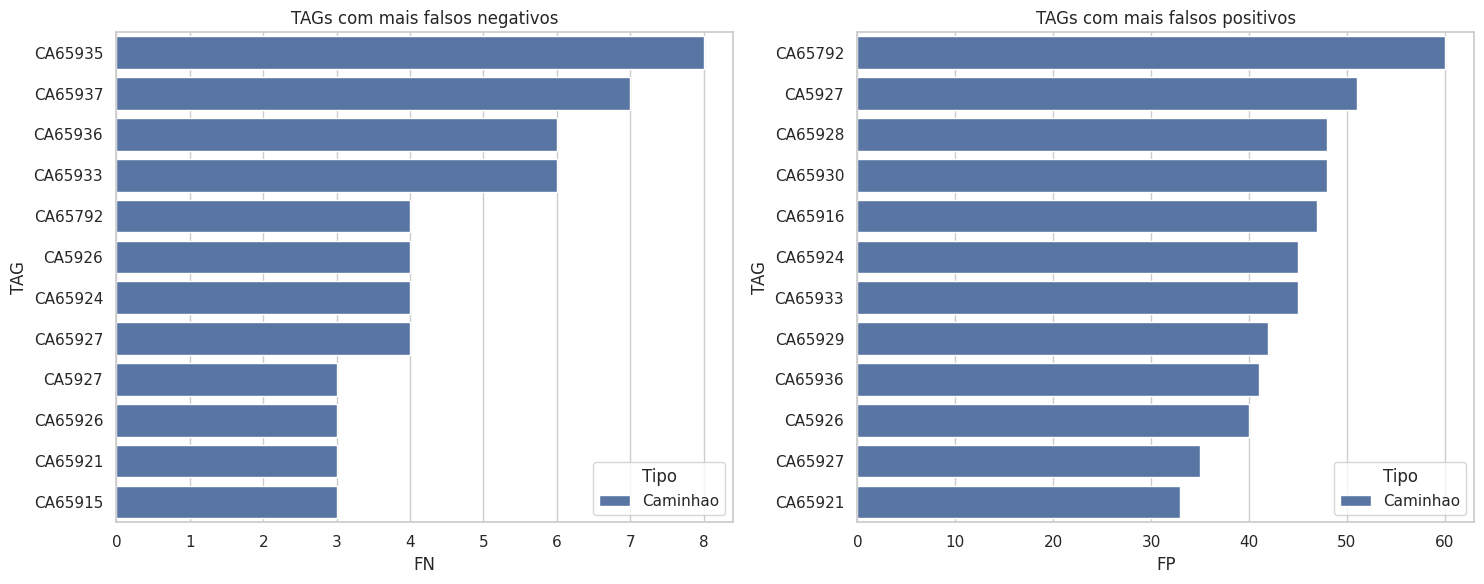

In [5]:
def summarize_group(df, group_cols):
    out = (
        df.assign(
            TP=(df["erro"] == "TP").astype(int),
            FP=(df["erro"] == "FP").astype(int),
            FN=(df["erro"] == "FN").astype(int),
            TN=(df["erro"] == "TN").astype(int),
        )
        .groupby(group_cols, dropna=False)
        .agg(
            amostras=("target", "size"),
            positivos_reais=("target", "sum"),
            positivos_previstos=("predito", "sum"),
            TP=("TP", "sum"),
            FP=("FP", "sum"),
            FN=("FN", "sum"),
            TN=("TN", "sum"),
            prob_media=("probabilidade", "mean"),
            prob_p90=("probabilidade", lambda x: x.quantile(.90)),
            eventos_medios=("sequencias_total", "mean"),
        )
        .reset_index()
    )
    out["precision"] = out["TP"] / (out["TP"] + out["FP"]).replace(0, np.nan)
    out["recall"] = out["TP"] / (out["TP"] + out["FN"]).replace(0, np.nan)
    out["taxa_fp"] = out["FP"] / (out["FP"] + out["TN"]).replace(0, np.nan)
    out["prevalencia"] = out["positivos_reais"] / out["amostras"]
    return out

tag_audit = summarize_group(predictions, ["TAG", "Tipo", "Tag_Frota"])
display(tag_audit.sort_values(["FN", "positivos_reais"], ascending=False).head(15))
display(tag_audit.sort_values(["FP", "positivos_previstos"], ascending=False).head(15))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.barplot(
    data=tag_audit.sort_values("FN", ascending=False).head(12),
    x="FN", y="TAG", hue="Tipo", dodge=False, ax=axes[0]
)
axes[0].set(title="TAGs com mais falsos negativos")
sns.barplot(
    data=tag_audit.sort_values("FP", ascending=False).head(12),
    x="FP", y="TAG", hue="Tipo", dodge=False, ax=axes[1]
)
axes[1].set(title="TAGs com mais falsos positivos")
plt.tight_layout()
plt.show()

## 4. Auditoria por tipo de equipamento

Esta leitura separa possível problema de equipamento específico de problema de classe operacional.
Se um tipo inteiro concentrar erros, pode justificar features ou modelos segmentados. Se o erro ficar
em poucas `TAGs`, a investigação deve começar nelas.

,Tipo,amostras,positivos_reais,positivos_previstos,TP,FP,FN,TN,prob_media,prob_p90,eventos_medios,precision,recall,taxa_fp,prevalencia
0,Caminhao,2670,288,1038,218,820,70,1562,0.206883,0.389586,127.422846,0.210019,0.756944,0.344249,0.107865
1,Escavadeira,445,2,0,0,0,2,443,0.024088,0.071657,954.716854,NaN,0.000000,0.000000,0.004494


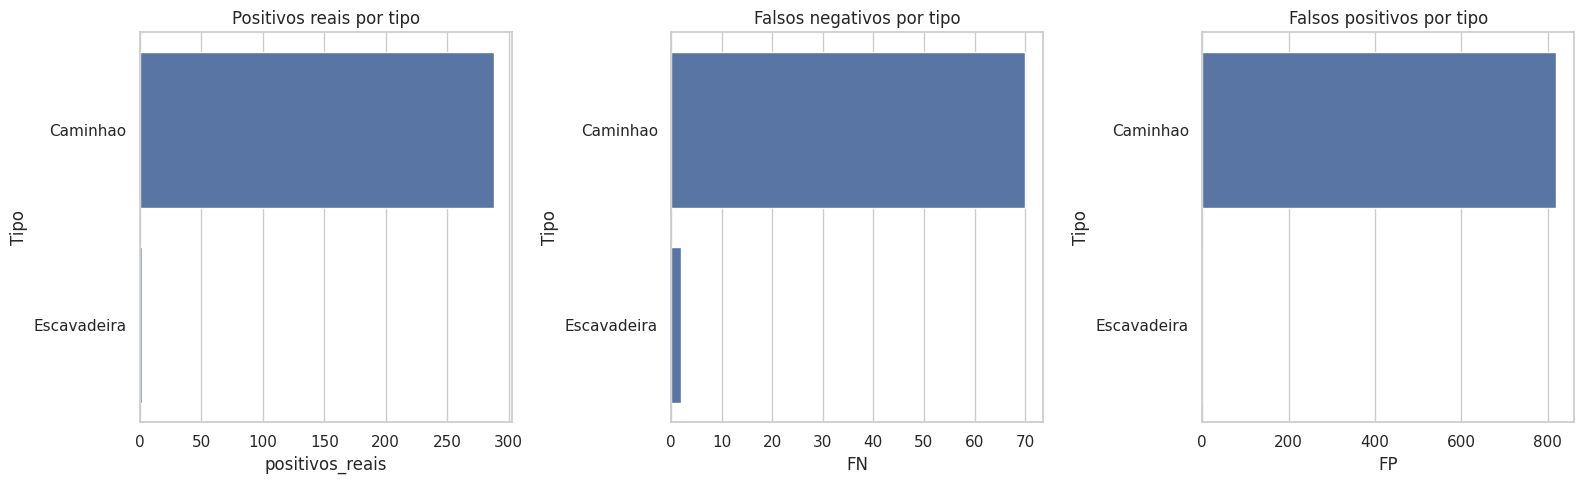

In [6]:
tipo_audit = summarize_group(predictions, ["Tipo"])
display(tipo_audit.sort_values("FN", ascending=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sns.barplot(data=tipo_audit.sort_values("positivos_reais", ascending=False), x="positivos_reais", y="Tipo", ax=axes[0])
axes[0].set(title="Positivos reais por tipo")
sns.barplot(data=tipo_audit.sort_values("FN", ascending=False), x="FN", y="Tipo", ax=axes[1])
axes[1].set(title="Falsos negativos por tipo")
sns.barplot(data=tipo_audit.sort_values("FP", ascending=False), x="FP", y="Tipo", ax=axes[2])
axes[2].set(title="Falsos positivos por tipo")
plt.tight_layout()
plt.show()

## 5. Auditoria temporal

Como o split é temporal, precisamos verificar se os erros se acumulam em algum trecho de junho. Isso
pode indicar mudança de regime, efeito residual da lacuna de 31/05 ou concentração de eventos em um
dia específico.

,data,amostras,positivos_reais,positivos_previstos,TP,FP,FN,TN,prob_media,prob_p90,eventos_medios,precision,recall,taxa_fp,prevalencia
21,2025-06-22,105,15,37,8,29,7,61,0.181453,0.375731,279.495238,0.216216,0.533333,0.322222,0.142857
23,2025-06-24,105,16,38,10,28,6,61,0.154733,0.303830,273.219048,0.263158,0.625000,0.314607,0.152381
19,2025-06-20,105,7,33,2,31,5,67,0.176988,0.319444,244.885714,0.060606,0.285714,0.316327,0.066667
25,2025-06-26,105,12,32,8,24,4,69,0.169859,0.287708,247.895238,0.250000,0.666667,0.258065,0.114286
1,2025-06-02,105,13,31,9,22,4,70,0.155788,0.296737,264.952381,0.290323,0.692308,0.239130,0.123810
4,2025-06-05,105,11,36,7,29,4,65,0.203027,0.494413,250.123810,0.194444,0.636364,0.308511,0.104762
29,2025-06-30,105,13,34,9,25,4,67,0.185320,0.368772,261.885714,0.264706,0.692308,0.271739,0.123810
28,2025-06-29,105,9,34,6,28,3,68,0.179860,0.340570,244.123810,0.176471,0.666667,0.291667,0.085714
22,2025-06-23,105,10,34,7,27,3,68,0.164561,0.311848,258.609524,0.205882,0.700000,0.284211,0.095238
26,2025-06-27,105,10,34,7,27,3,68,0.194079,0.381469,234.466667,0.205882,0.700000,0.284211,0.095238


,data,amostras,positivos_reais,positivos_previstos,TP,FP,FN,TN,prob_media,prob_p90,eventos_medios,precision,recall,taxa_fp,prevalencia
16,2025-06-17,105,7,41,6,35,1,63,0.178787,0.371873,216.904762,0.146341,0.857143,0.357143,0.066667
17,2025-06-18,105,8,38,6,32,2,65,0.168106,0.299627,235.819048,0.157895,0.750000,0.329897,0.076190
11,2025-06-12,105,6,35,4,31,2,68,0.179777,0.370147,214.819048,0.114286,0.666667,0.313131,0.057143
19,2025-06-20,105,7,33,2,31,5,67,0.176988,0.319444,244.885714,0.060606,0.285714,0.316327,0.066667
5,2025-06-06,105,10,40,9,31,1,64,0.212625,0.457565,255.342857,0.225000,0.900000,0.326316,0.095238
2,2025-06-03,105,7,37,6,31,1,67,0.184159,0.447733,232.904762,0.162162,0.857143,0.316327,0.066667
18,2025-06-19,105,9,38,7,31,2,65,0.191575,0.326163,280.057143,0.184211,0.777778,0.322917,0.085714
27,2025-06-28,105,7,37,6,31,1,67,0.183021,0.381019,241.704762,0.162162,0.857143,0.316327,0.066667
21,2025-06-22,105,15,37,8,29,7,61,0.181453,0.375731,279.495238,0.216216,0.533333,0.322222,0.142857
4,2025-06-05,105,11,36,7,29,4,65,0.203027,0.494413,250.123810,0.194444,0.636364,0.308511,0.104762


,hora_previsao,amostras,positivos_reais,positivos_previstos,TP,FP,FN,TN,prob_media,prob_p90,eventos_medios,precision,recall,taxa_fp,prevalencia
0,0,1015,95,338,71,267,24,653,0.178101,0.348862,246.888670,0.210059,0.747368,0.290217,0.093596
1,8,1050,98,358,77,281,21,671,0.183993,0.381019,245.036190,0.215084,0.785714,0.295168,0.093333
2,16,1050,97,342,70,272,27,681,0.180125,0.357901,244.940952,0.204678,0.721649,0.285414,0.092381


,semana,amostras,positivos_reais,positivos_previstos,TP,FP,FN,TN,prob_media,prob_p90,eventos_medios,precision,recall,taxa_fp,prevalencia
0,2025-05-26/2025-06-01,70,4,23,4,19,0,47,0.173242,0.343851,267.657143,0.173913,1.000000,0.287879,0.057143
1,2025-06-02/2025-06-08,735,65,235,51,184,14,486,0.185824,0.386843,242.770068,0.217021,0.784615,0.274627,0.088435
2,2025-06-09/2025-06-15,735,70,248,56,192,14,473,0.188771,0.405489,231.057143,0.225806,0.800000,0.288722,0.095238
3,2025-06-16/2025-06-22,735,65,256,47,209,18,461,0.175838,0.338172,252.951020,0.183594,0.723077,0.311940,0.088435
4,2025-06-23/2025-06-29,735,73,242,51,191,22,471,0.172711,0.334373,251.227211,0.210744,0.698630,0.288520,0.099320
5,2025-06-30/2025-07-06,105,13,34,9,25,4,67,0.185320,0.368772,261.885714,0.264706,0.692308,0.271739,0.123810


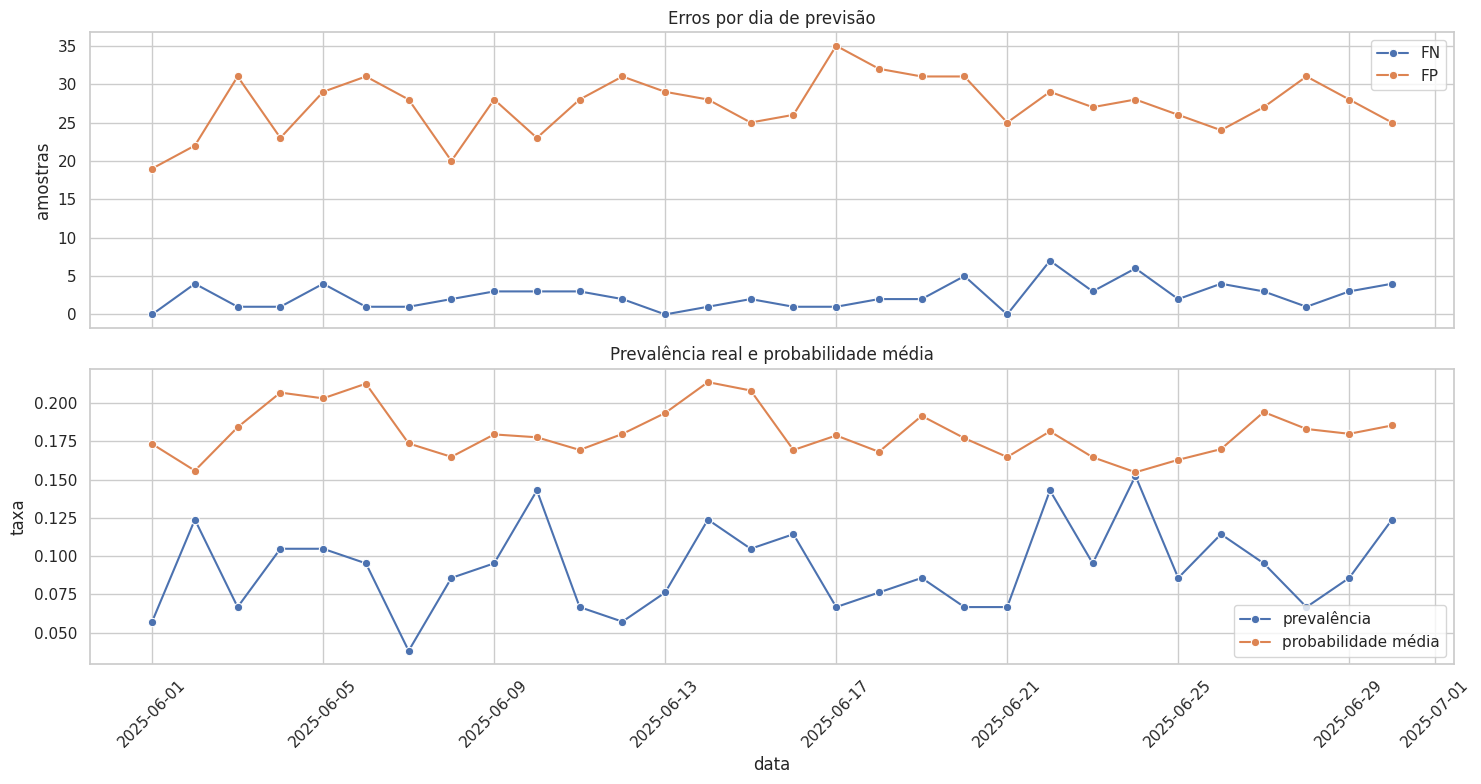

In [7]:
predictions["data"] = predictions["prediction_time"].dt.date
predictions["hora_previsao"] = predictions["prediction_time"].dt.hour
predictions["semana"] = predictions["prediction_time"].dt.to_period("W").astype(str)

daily_audit = summarize_group(predictions, ["data"])
hour_audit = summarize_group(predictions, ["hora_previsao"])
week_audit = summarize_group(predictions, ["semana"])

display(daily_audit.sort_values("FN", ascending=False).head(15))
display(daily_audit.sort_values("FP", ascending=False).head(15))
display(hour_audit)
display(week_audit)

fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
sns.lineplot(data=daily_audit, x="data", y="FN", marker="o", ax=axes[0], label="FN")
sns.lineplot(data=daily_audit, x="data", y="FP", marker="o", ax=axes[0], label="FP")
axes[0].set(title="Erros por dia de previsão", ylabel="amostras")
sns.lineplot(data=daily_audit, x="data", y="prevalencia", marker="o", ax=axes[1], label="prevalência")
sns.lineplot(data=daily_audit, x="data", y="prob_media", marker="o", ax=axes[1], label="probabilidade média")
axes[1].set(title="Prevalência real e probabilidade média", ylabel="taxa")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 6. Probabilidades e sensibilidade do threshold

O threshold foi escolhido para maximizar F2 na validação. Aqui observamos se, em junho, os positivos
ficam de fato mais concentrados nas faixas altas de probabilidade e quantos erros estão próximos do
threshold.

,faixa_probabilidade,amostras,positivos,taxa_positiva
0,"(-0.001, 0.1]",1046,15,0.014340
1,"(0.1, 0.2]",992,55,0.055444
2,"(0.2, 0.3]",590,75,0.127119
3,"(0.3, 0.4]",238,56,0.235294
4,"(0.4, 0.5]",83,18,0.216867
5,"(0.5, 0.6]",54,16,0.296296
6,"(0.6, 0.7]",58,25,0.431034
7,"(0.7, 0.8]",43,25,0.581395
8,"(0.8, 0.9]",11,5,0.454545
9,"(0.9, 1.0]",0,0,NaN


,erro,amostras_proximas_do_threshold
0,TN,391
1,FP,315
2,TP,44
3,FN,38


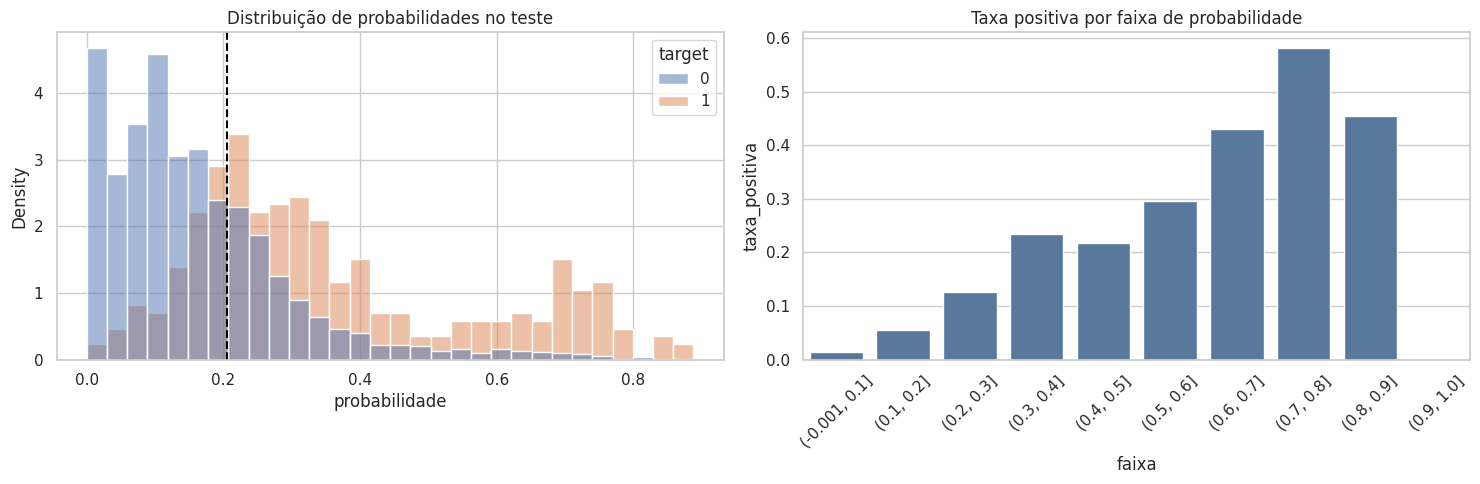

In [8]:
prob_bins = np.linspace(0, 1, 11)
prob_audit = (
    predictions.assign(faixa_probabilidade=pd.cut(predictions["probabilidade"], prob_bins, include_lowest=True))
    .groupby("faixa_probabilidade", observed=False)
    .agg(amostras=("target", "size"), positivos=("target", "sum"), taxa_positiva=("target", "mean"))
    .reset_index()
)
display(prob_audit)

near_threshold = predictions[
    predictions["probabilidade"].between(threshold - 0.05, threshold + 0.05)
].copy()
display(
    near_threshold["erro"]
    .value_counts()
    .rename_axis("erro")
    .reset_index(name="amostras_proximas_do_threshold")
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(data=predictions, x="probabilidade", hue="target", bins=30, stat="density", common_norm=False, ax=axes[0])
axes[0].axvline(threshold, color="black", linestyle="--")
axes[0].set(title="Distribuição de probabilidades no teste")
sns.barplot(data=prob_audit, x="faixa_probabilidade", y="taxa_positiva", ax=axes[1], color="#4C78A8")
axes[1].set(title="Taxa positiva por faixa de probabilidade", xlabel="faixa")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## 7. Drill down dos erros

Os casos abaixo não são removidos nem corrigidos automaticamente. Eles servem para escolher a próxima
investigação:

- falsos negativos com maior probabilidade mostram casos quase capturados pelo threshold;
- falsos negativos com baixa probabilidade indicam padrões ausentes nas features atuais;
- falsos positivos com maior probabilidade mostram recorrências que o modelo trata como risco, mas
  sem episódio positivo no horizonte.

In [9]:
fn_high = predictions[predictions["erro"] == "FN"].sort_values("probabilidade", ascending=False).head(15)
fn_low = predictions[predictions["erro"] == "FN"].sort_values("probabilidade", ascending=True).head(15)
fp_high = predictions[predictions["erro"] == "FP"].sort_values("probabilidade", ascending=False).head(15)

print("Falsos negativos mais próximos/acima do padrão de risco:")
display(fn_high)
print("Falsos negativos com baixa probabilidade:")
display(fn_low)
print("Falsos positivos com maior probabilidade:")
display(fp_high)

Falsos negativos mais próximos/acima do padrão de risco:


,TAG,Tipo,Tag_Frota,feature_start,prediction_time,target_end,sequencias_total,alarmes_distintos,registros_analiticos,episodios_dont_go_target,target,probabilidade,predito,erro,data,hora_previsao,semana
18098,CA65790,Caminhao,793-D 2S,2025-06-23 16:00:00,2025-06-24 00:00:00,2025-06-24 08:00:00,217,18,253.0,1.0,1,0.201666,0,FN,2025-06-24,0,2025-06-23/2025-06-29
17764,CA65927,Caminhao,793-D 5S,2025-06-20 08:00:00,2025-06-20 16:00:00,2025-06-21 00:00:00,46,14,61.0,8.0,1,0.201182,0,FN,2025-06-20,16,2025-06-16/2025-06-22
16513,CA65936,Caminhao,793-D 5S,2025-06-08 08:00:00,2025-06-08 16:00:00,2025-06-09 00:00:00,195,17,301.0,1.0,1,0.195100,0,FN,2025-06-08,16,2025-06-02/2025-06-08
17910,CA65933,Caminhao,793-D 5S,2025-06-21 16:00:00,2025-06-22 00:00:00,2025-06-22 08:00:00,197,20,264.0,10.0,1,0.193598,0,FN,2025-06-22,0,2025-06-16/2025-06-22
17898,CA65921,Caminhao,793-D 4S,2025-06-21 16:00:00,2025-06-22 00:00:00,2025-06-22 08:00:00,19,6,20.0,1.0,1,0.193389,0,FN,2025-06-22,0,2025-06-16/2025-06-22
18307,CA65789,Caminhao,793-D 2S,2025-06-25 16:00:00,2025-06-26 00:00:00,2025-06-26 08:00:00,49,9,89.0,1.0,1,0.193316,0,FN,2025-06-26,0,2025-06-23/2025-06-29
18280,CA65915,Caminhao,793-D 4S,2025-06-25 08:00:00,2025-06-25 16:00:00,2025-06-26 00:00:00,284,15,332.0,2.0,1,0.192695,0,FN,2025-06-25,16,2025-06-23/2025-06-29
17509,CA65909,Caminhao,793-D 3S,2025-06-18 00:00:00,2025-06-18 08:00:00,2025-06-18 16:00:00,307,20,360.0,1.0,1,0.192023,0,FN,2025-06-18,8,2025-06-16/2025-06-22
16164,CA65937,Caminhao,793-D 5S,2025-06-05 00:00:00,2025-06-05 08:00:00,2025-06-05 16:00:00,137,20,159.0,2.0,1,0.190648,0,FN,2025-06-05,8,2025-06-02/2025-06-08
16595,CA65792,Caminhao,793-D 2S,2025-06-09 08:00:00,2025-06-09 16:00:00,2025-06-10 00:00:00,127,22,146.0,1.0,1,0.188585,0,FN,2025-06-09,16,2025-06-09/2025-06-15


Falsos negativos com baixa probabilidade:


,TAG,Tipo,Tag_Frota,feature_start,prediction_time,target_end,sequencias_total,alarmes_distintos,registros_analiticos,episodios_dont_go_target,target,probabilidade,predito,erro,data,hora_previsao,semana
15852,PE3797,Escavadeira,LeTourneau L 1850,2025-06-02 00:00:00,2025-06-02 08:00:00,2025-06-02 16:00:00,764,33,10230.0,1.0,1,0.004181,0,FN,2025-06-02,8,2025-06-02/2025-06-08
18440,PE3795,Escavadeira,LeTourneau L 1850,2025-06-26 16:00:00,2025-06-27 00:00:00,2025-06-27 08:00:00,1315,36,17713.0,3.0,1,0.025002,0,FN,2025-06-27,0,2025-06-23/2025-06-29
16829,CA65937,Caminhao,793-D 5S,2025-06-11 08:00:00,2025-06-11 16:00:00,2025-06-12 00:00:00,146,14,190.0,7.0,1,0.050613,0,FN,2025-06-11,16,2025-06-09/2025-06-15
16660,CA5926,Caminhao,793-D 5S,2025-06-10 00:00:00,2025-06-10 08:00:00,2025-06-10 16:00:00,0,0,0.0,5.0,1,0.052227,0,FN,2025-06-10,8,2025-06-09/2025-06-15
16094,CA65937,Caminhao,793-D 5S,2025-06-04 08:00:00,2025-06-04 16:00:00,2025-06-05 00:00:00,155,15,207.0,2.0,1,0.058050,0,FN,2025-06-04,16,2025-06-02/2025-06-08
18708,CA65926,Caminhao,793-D 4S,2025-06-29 08:00:00,2025-06-29 16:00:00,2025-06-30 00:00:00,1,1,1.0,59.0,1,0.058749,0,FN,2025-06-29,16,2025-06-23/2025-06-29
18731,CA65793,Caminhao,793-D 2S,2025-06-29 16:00:00,2025-06-30 00:00:00,2025-06-30 08:00:00,160,14,206.0,1.0,1,0.070139,0,FN,2025-06-30,0,2025-06-30/2025-07-06
15873,CA65926,Caminhao,793-D 4S,2025-06-02 08:00:00,2025-06-02 16:00:00,2025-06-03 00:00:00,0,0,0.0,2.0,1,0.072142,0,FN,2025-06-02,16,2025-06-02/2025-06-08
17352,CA65935,Caminhao,793-D 5S,2025-06-16 08:00:00,2025-06-16 16:00:00,2025-06-17 00:00:00,0,0,0.0,2.0,1,0.072142,0,FN,2025-06-16,16,2025-06-16/2025-06-22
18534,CA65927,Caminhao,793-D 5S,2025-06-27 16:00:00,2025-06-28 00:00:00,2025-06-28 08:00:00,0,0,0.0,19.0,1,0.078761,0,FN,2025-06-28,0,2025-06-23/2025-06-29


Falsos positivos com maior probabilidade:


,TAG,Tipo,Tag_Frota,feature_start,prediction_time,target_end,sequencias_total,alarmes_distintos,registros_analiticos,episodios_dont_go_target,target,probabilidade,predito,erro,data,hora_previsao,semana
16057,CA65935,Caminhao,793-D 5S,2025-06-04 00:00:00,2025-06-04 08:00:00,2025-06-04 16:00:00,365,22,553.0,0.0,0,0.871784,1,FP,2025-06-04,8,2025-06-02/2025-06-08
16232,CA65935,Caminhao,793-D 5S,2025-06-05 16:00:00,2025-06-06 00:00:00,2025-06-06 08:00:00,322,22,476.0,0.0,0,0.832897,1,FP,2025-06-06,0,2025-06-02/2025-06-08
17093,CA65921,Caminhao,793-D 4S,2025-06-14 00:00:00,2025-06-14 08:00:00,2025-06-14 16:00:00,88,15,147.0,0.0,0,0.824918,1,FP,2025-06-14,8,2025-06-09/2025-06-15
16084,CA65927,Caminhao,793-D 5S,2025-06-04 08:00:00,2025-06-04 16:00:00,2025-06-05 00:00:00,112,20,160.0,0.0,0,0.823552,1,FP,2025-06-04,16,2025-06-02/2025-06-08
16299,CA65932,Caminhao,793-D 5S,2025-06-06 08:00:00,2025-06-06 16:00:00,2025-06-07 00:00:00,101,13,148.0,0.0,0,0.816695,1,FP,2025-06-06,16,2025-06-02/2025-06-08
15763,CA65921,Caminhao,793-D 4S,2025-06-01 08:00:00,2025-06-01 16:00:00,2025-06-02 00:00:00,91,17,145.0,0.0,0,0.802037,1,FP,2025-06-01,16,2025-05-26/2025-06-01
18384,CA65909,Caminhao,793-D 3S,2025-06-26 08:00:00,2025-06-26 16:00:00,2025-06-27 00:00:00,350,20,727.0,0.0,0,0.793607,1,FP,2025-06-26,16,2025-06-23/2025-06-29
17614,CA65909,Caminhao,793-D 3S,2025-06-19 00:00:00,2025-06-19 08:00:00,2025-06-19 16:00:00,329,19,384.0,0.0,0,0.766642,1,FP,2025-06-19,8,2025-06-16/2025-06-22
16684,CA65932,Caminhao,793-D 5S,2025-06-10 00:00:00,2025-06-10 08:00:00,2025-06-10 16:00:00,77,20,112.0,0.0,0,0.765258,1,FP,2025-06-10,8,2025-06-09/2025-06-15
17238,CA65926,Caminhao,793-D 4S,2025-06-15 08:00:00,2025-06-15 16:00:00,2025-06-16 00:00:00,110,14,170.0,0.0,0,0.750829,1,FP,2025-06-15,16,2025-06-09/2025-06-15


In [10]:
def sequence_context(rows, label):
    if rows.empty:
        print(f"Sem casos para {label}.")
        return pd.DataFrame()
    clauses = []
    for row in rows.itertuples(index=False):
        clauses.append(
            f"(TAG = '{row.TAG}' AND inicio >= TIMESTAMP '{row.feature_start}' "
            f"AND inicio < TIMESTAMP '{row.target_end}')"
        )
    where_clause = " OR ".join(clauses)
    result = query(
        f'''
        SELECT
            '{label}' AS grupo,
            TAG, Tipo, Id_Alarme, Alarme, inicio, fim, duracao_ms,
            registros_analiticos, registros_brutos_representados, is_dont_go,
            possui_critico, possui_activate, possui_inactive, possui_classe_nula
        FROM alarm_sequences
        WHERE {where_clause}
        ORDER BY TAG, inicio, is_dont_go DESC, registros_analiticos DESC
        '''
    )
    return result

context_rows = pd.concat([
    sequence_context(fn_high.head(5), "FN_alta_probabilidade"),
    sequence_context(fn_low.head(5), "FN_baixa_probabilidade"),
    sequence_context(fp_high.head(5), "FP_alta_probabilidade"),
], ignore_index=True)

display(context_rows.head(200))

,grupo,TAG,Tipo,Id_Alarme,Alarme,inicio,fim,duracao_ms,registros_analiticos,registros_brutos_representados,is_dont_go,possui_critico,possui_activate,possui_inactive,possui_classe_nula
0,FN_alta_probabilidade,CA65790,Caminhao,335609901,4th Tire Tag Timeout,2025-06-23 16:01:46.257,2025-06-23 16:01:46.257,0,1,1.0,0,0,0,0,0
1,FN_alta_probabilidade,CA65790,Caminhao,335609914,5th Tire Tag Timeout,2025-06-23 16:01:46.257,2025-06-23 16:01:46.257,0,1,1.0,0,0,0,0,0
2,FN_alta_probabilidade,CA65790,Caminhao,335609927,6th Tire Tag Timeout,2025-06-23 16:01:46.257,2025-06-23 16:01:46.257,0,1,1.0,0,0,0,0,0
3,FN_alta_probabilidade,CA65790,Caminhao,335609875,2nd Tire Tag Timeout,2025-06-23 16:01:46.257,2025-06-23 16:01:46.257,0,1,1.0,0,0,0,0,0
4,FN_alta_probabilidade,CA65790,Caminhao,335609862,1st Tire Tag Timeout,2025-06-23 16:01:46.257,2025-06-23 16:01:46.257,0,1,1.0,0,0,0,0,0
5,FN_alta_probabilidade,CA65790,Caminhao,335609888,3rd Tire Tag Timeout,2025-06-23 16:01:46.257,2025-06-23 16:01:46.257,0,1,1.0,0,0,0,0,0
6,FN_alta_probabilidade,CA65790,Caminhao,84672481,Oem Interface Normal,2025-06-23 16:06:32.737,2025-06-23 16:06:32.737,0,1,1.0,0,0,0,0,0
7,FN_alta_probabilidade,CA65790,Caminhao,84672480,Oem Interface Timeout,2025-06-23 16:07:42.187,2025-06-23 16:07:42.187,0,1,1.0,0,0,0,0,0
8,FN_alta_probabilidade,CA65790,Caminhao,84672481,Oem Interface Normal,2025-06-23 16:08:53.103,2025-06-23 16:08:53.103,0,1,1.0,0,0,0,0,0
9,FN_alta_probabilidade,CA65790,Caminhao,335609934,Rx Channel A Not Receiving Messages,2025-06-23 16:09:43.880,2025-06-23 16:09:43.880,0,1,1.0,0,0,0,0,0


## 8. Escavadeiras: evidência disponível

A hipótese operacional é que uma escavadeira parada pode causar impacto em cascata maior que um
caminhão parado. Este dataset, porém, não traz custo financeiro observado por equipamento. Portanto,
esta seção mede apenas:

- quantas escavadeiras existem na telemetria analítica;
- quantos episódios `Is_Dont_Go` aparecem para elas;
- como o baseline erra ou acerta esse recorte no teste.

Qualquer priorização por custo deve entrar depois como premissa externa documentada ou como dado real
de custo/parada, não como conclusão deste dataset.

In [11]:
def is_excavator_series(series):
    return series.fillna("").str.contains("ESCAV", case=False, regex=True)

tag_profile_full = query(
    '''
    SELECT
        TAG,
        any_value(Tipo) AS Tipo,
        any_value(Tag_Frota) AS Tag_Frota,
        count(*) AS registros_analiticos,
        sum(Is_Dont_Go) AS linhas_dont_go,
        count(DISTINCT Id_Alarme) AS alarmes_distintos,
        min(Data_Evento) AS inicio,
        max(Data_Evento) AS fim
    FROM analytic_events
    GROUP BY 1
    ORDER BY Tipo, TAG
    '''
)
tag_profile_full["eh_escavadeira"] = is_excavator_series(tag_profile_full["Tipo"])
display(
    tag_profile_full.groupby(["eh_escavadeira", "Tipo"], dropna=False)
    .agg(
        tags=("TAG", "nunique"),
        registros_analiticos=("registros_analiticos", "sum"),
        linhas_dont_go=("linhas_dont_go", "sum"),
        alarmes_distintos=("alarmes_distintos", "sum"),
    )
    .reset_index()
    .sort_values(["eh_escavadeira", "linhas_dont_go"], ascending=[False, False])
)

sequence_type_audit = query(
    '''
    SELECT
        Tipo,
        count(*) AS sequencias,
        sum(is_dont_go) AS sequencias_dont_go,
        count(DISTINCT TAG) AS tags,
        count(DISTINCT Id_Alarme) AS alarmes_distintos
    FROM alarm_sequences
    GROUP BY 1
    ORDER BY sequencias_dont_go DESC
    '''
)
sequence_type_audit["eh_escavadeira"] = is_excavator_series(sequence_type_audit["Tipo"])
display(sequence_type_audit)

predictions["eh_escavadeira"] = is_excavator_series(predictions["Tipo"])
excavator_test_audit = summarize_group(predictions, ["eh_escavadeira", "Tipo"])
display(excavator_test_audit.sort_values(["eh_escavadeira", "FN"], ascending=[False, False]))

display(
    predictions[predictions["eh_escavadeira"]]
    .sort_values(["target", "probabilidade"], ascending=[False, False])
    .head(100)
)

,eh_escavadeira,Tipo,tags,registros_analiticos,linhas_dont_go,alarmes_distintos
1,True,Escavadeira,5,32347375,167.0,924
0,False,Caminhao,30,3260719,19774.0,5926


,Tipo,sequencias,sequencias_dont_go,tags,alarmes_distintos,eh_escavadeira
0,Caminhao,2146968,14445.0,30,1025,False
1,Escavadeira,2156657,167.0,5,299,True


,eh_escavadeira,Tipo,amostras,positivos_reais,positivos_previstos,TP,FP,FN,TN,prob_media,prob_p90,eventos_medios,precision,recall,taxa_fp,prevalencia
1,True,Escavadeira,445,2,0,0,0,2,443,0.024088,0.071657,954.716854,NaN,0.000000,0.000000,0.004494
0,False,Caminhao,2670,288,1038,218,820,70,1562,0.206883,0.389586,127.422846,0.210019,0.756944,0.344249,0.107865


,TAG,Tipo,Tag_Frota,feature_start,prediction_time,target_end,sequencias_total,alarmes_distintos,registros_analiticos,episodios_dont_go_target,target,probabilidade,predito,erro,data,hora_previsao,semana,eh_escavadeira
18440,PE3795,Escavadeira,LeTourneau L 1850,2025-06-26 16:00:00,2025-06-27 00:00:00,2025-06-27 08:00:00,1315,36,17713.0,3.0,1,0.025002,0,FN,2025-06-27,0,2025-06-23/2025-06-29,True
15852,PE3797,Escavadeira,LeTourneau L 1850,2025-06-02 00:00:00,2025-06-02 08:00:00,2025-06-02 16:00:00,764,33,10230.0,1.0,1,0.004181,0,FN,2025-06-02,8,2025-06-02/2025-06-08,True
17008,PE3798,Escavadeira,LeTourneau L 1850,2025-06-13 00:00:00,2025-06-13 08:00:00,2025-06-13 16:00:00,0,0,0.0,0.0,0,0.164888,0,TN,2025-06-13,8,2025-06-09/2025-06-15,True
18545,PE3795,Escavadeira,LeTourneau L 1850,2025-06-27 16:00:00,2025-06-28 00:00:00,2025-06-28 08:00:00,17,9,23.0,0.0,0,0.145721,0,TN,2025-06-28,0,2025-06-23/2025-06-29,True
17043,PE3798,Escavadeira,LeTourneau L 1850,2025-06-13 08:00:00,2025-06-13 16:00:00,2025-06-14 00:00:00,0,0,0.0,0.0,0,0.132365,0,TN,2025-06-13,16,2025-06-09/2025-06-15,True
18511,PE3796,Escavadeira,LeTourneau L 1850,2025-06-27 08:00:00,2025-06-27 16:00:00,2025-06-28 00:00:00,0,0,0.0,0.0,0,0.132365,0,TN,2025-06-27,16,2025-06-23/2025-06-29,True
17603,PE3798,Escavadeira,LeTourneau L 1850,2025-06-18 16:00:00,2025-06-19 00:00:00,2025-06-19 08:00:00,678,39,5080.0,0.0,0,0.124917,0,TN,2025-06-19,0,2025-06-16/2025-06-22,True
17427,PE3797,Escavadeira,LeTourneau L 1850,2025-06-17 00:00:00,2025-06-17 08:00:00,2025-06-17 16:00:00,782,103,848.0,0.0,0,0.122820,0,TN,2025-06-17,8,2025-06-16/2025-06-22,True
16027,PE3797,Escavadeira,LeTourneau L 1850,2025-06-03 16:00:00,2025-06-04 00:00:00,2025-06-04 08:00:00,0,0,0.0,0.0,0,0.111771,0,TN,2025-06-04,0,2025-06-02/2025-06-08,True
16762,PE3797,Escavadeira,LeTourneau L 1850,2025-06-10 16:00:00,2025-06-11 00:00:00,2025-06-11 08:00:00,0,0,0.0,0.0,0,0.111771,0,TN,2025-06-11,0,2025-06-09/2025-06-15,True


## 9. Alarmes associados aos erros

Aqui ligamos cada janela de teste às sequências de alarme observadas nas 8 horas anteriores e aos
episódios no horizonte. Essa leitura evita criar famílias por similaridade textual ampla antes de
saber quais alarmes realmente aparecem nos erros.

In [12]:
con.register("predictions_df", predictions)

obs_error_alarm = query(
    '''
    SELECT
        p.erro,
        p.Tipo,
        s.Id_Alarme,
        any_value(s.Alarme) AS Alarme,
        count(*) AS sequencias_observadas,
        count(DISTINCT p.TAG || '|' || CAST(p.feature_start AS VARCHAR)) AS janelas,
        count(DISTINCT p.TAG) AS tags,
        sum(s.is_dont_go) AS sequencias_observadas_dont_go,
        avg(p.probabilidade) AS prob_media
    FROM predictions_df p
    JOIN alarm_sequences s
      ON s.TAG = p.TAG
     AND s.inicio >= p.feature_start
     AND s.inicio < p.prediction_time
    WHERE p.erro IN ('FP', 'FN')
    GROUP BY 1, 2, 3
    ORDER BY erro, janelas DESC, sequencias_observadas DESC
    '''
)

target_error_alarm = query(
    '''
    SELECT
        p.erro,
        p.Tipo,
        s.Id_Alarme,
        any_value(s.Alarme) AS Alarme,
        count(*) AS sequencias_no_horizonte,
        count(DISTINCT p.TAG || '|' || CAST(p.feature_start AS VARCHAR)) AS janelas,
        count(DISTINCT p.TAG) AS tags,
        sum(s.is_dont_go) AS sequencias_dont_go_no_horizonte,
        avg(p.probabilidade) AS prob_media
    FROM predictions_df p
    JOIN alarm_sequences s
      ON s.TAG = p.TAG
     AND s.inicio >= p.prediction_time
     AND s.inicio < p.target_end
    WHERE p.erro IN ('FP', 'FN')
    GROUP BY 1, 2, 3
    ORDER BY erro, sequencias_dont_go_no_horizonte DESC, janelas DESC
    '''
)

print("Alarmes na janela de observação dos erros:")
display(obs_error_alarm.groupby("erro").head(25))
print("Alarmes no horizonte dos erros:")
display(target_error_alarm.groupby("erro").head(25))

print("Recorte de escavadeiras na observação dos erros:")
display(obs_error_alarm[is_excavator_series(obs_error_alarm["Tipo"])].groupby("erro").head(25))
print("Recorte de escavadeiras no horizonte dos erros:")
display(target_error_alarm[is_excavator_series(target_error_alarm["Tipo"])].groupby("erro").head(25))

Alarmes na janela de observação dos erros:


,erro,Tipo,Id_Alarme,Alarme,sequencias_observadas,janelas,tags,sequencias_observadas_dont_go,prob_media
0,FN,Caminhao,84672480,Oem Interface Timeout,265,66,22,0.0,0.157995
1,FN,Caminhao,84672481,Oem Interface Normal,226,64,22,0.0,0.159344
2,FN,Caminhao,84626976,Dipper,682,62,22,0.0,0.151942
3,FN,Caminhao,84626978,Cycle,577,61,22,0.0,0.150247
4,FN,Caminhao,84626979,Body Up,579,60,22,0.0,0.150393
5,FN,Caminhao,84626977,Load,577,60,22,0.0,0.149745
6,FN,Caminhao,84612806,Payload Overload - Inactive,189,55,20,0.0,0.147698
7,FN,Caminhao,84612807,Payload Overload - Active,195,54,20,0.0,0.146427
8,FN,Caminhao,335609934,Rx Channel A Not Receiving Messages,1961,45,13,0.0,0.147964
9,FN,Caminhao,335609935,Rx Channel B Not Receiving Messages,1960,45,13,0.0,0.147954


Alarmes no horizonte dos erros:


,erro,Tipo,Id_Alarme,Alarme,sequencias_no_horizonte,janelas,tags,sequencias_dont_go_no_horizonte,prob_media
0,FN,Caminhao,84609435,Right Front Brake Temperature - Active,81,2,1,79.0,0.089882
1,FN,Caminhao,84613669,Transmission Oil Level - Active,87,30,12,58.0,0.155829
2,FN,Caminhao,84609911,Crankcase Pressure - Active,30,5,1,19.0,0.177188
3,FN,Caminhao,84609447,Right Rear Brake Temperature - Active,12,2,1,11.0,0.144509
4,FN,Caminhao,84608753,Engine Coolant Level - Active,75,19,13,9.0,0.170254
5,FN,Caminhao,84608399,Left Rear Brake Temperature - Active,22,13,11,9.0,0.127068
6,FN,Caminhao,84609807,Aftercooler Level - Active,8,7,4,8.0,0.168066
7,FN,Caminhao,84608397,Right Front Brake Temperature - Active,8,3,2,8.0,0.102329
8,FN,Caminhao,84607069,Aftercooler Level - Active,7,6,6,7.0,0.114907
9,FN,Caminhao,84609797,Engine Coolant Level - Active,7,5,3,7.0,0.155112


Recorte de escavadeiras na observação dos erros:


,erro,Tipo,Id_Alarme,Alarme,sequencias_observadas,janelas,tags,sequencias_observadas_dont_go,prob_media
53,FN,Escavadeira,1074008247,Lift Arms Too High (L-1850),215,2,2,0.0,0.018417
54,FN,Escavadeira,1074008262,Rollback Stick Limited By End Of Travel (L-1850),210,2,2,0.0,0.017764
55,FN,Escavadeira,1074008264,Bucket Load Weight (L-1850),174,2,2,0.0,0.018062
56,FN,Escavadeira,1074008259,Lower Hoist Limited By End Of Travel (L-1850),173,2,2,0.0,0.020308
57,FN,Escavadeira,1074008235,Bucket Angle At Or Above Level (L-1850),166,2,2,0.0,0.018480
58,FN,Escavadeira,1074008257,Dump Wheel Limited By End Of Travel (L-1850),130,2,2,0.0,0.016994
59,FN,Escavadeira,1241579528,Engine \/ Retarder Torque Mode - Torque Limiting,125,2,2,0.0,0.019838
60,FN,Escavadeira,1074008261,Right Steer Limited By End Of Travel (L-1850),115,2,2,0.0,0.019027
61,FN,Escavadeira,1241579521,Engine \/ Retarder Torque Mode - Accelerator P...,105,2,2,0.0,0.015484
62,FN,Escavadeira,1074008258,Left Steer Limited By End Of Travel (L-1850),102,2,2,0.0,0.016225


Recorte de escavadeiras no horizonte dos erros:


,erro,Tipo,Id_Alarme,Alarme,sequencias_no_horizonte,janelas,tags,sequencias_dont_go_no_horizonte,prob_media
19,FN,Escavadeira,1074008051,Hydraulic Reservoir Oil Temperature Critically...,3,1,1,3.0,0.025002
23,FN,Escavadeira,1074007982,HPD Gearbox Oil Pressure Critically Low (L-1850),1,1,1,1.0,0.004181
103,FN,Escavadeira,1241579532,Engine \/ Retarder Torque Mode - Not Defined\/...,59,2,2,0.0,0.019003
105,FN,Escavadeira,1074008247,Lift Arms Too High (L-1850),69,2,2,0.0,0.024700
106,FN,Escavadeira,1074008249,Park Brakes Not Released (L-1850),30,2,2,0.0,0.014592
107,FN,Escavadeira,1074069473,Oem Interface Normal,17,2,2,0.0,0.013979
112,FN,Escavadeira,1074008238,Engine At High Throttle (L-1850),21,2,2,0.0,0.020045
115,FN,Escavadeira,1241645025,Oem Interface Normal,22,2,2,0.0,0.012699
116,FN,Escavadeira,1074008259,Lower Hoist Limited By End Of Travel (L-1850),102,2,2,0.0,0.023165
119,FN,Escavadeira,1241579521,Engine \/ Retarder Torque Mode - Accelerator P...,61,2,2,0.0,0.019541


## 10. Candidatos iniciais de conceito de alarme

Esta seção cria uma normalização textual simples para apoiar inspeção humana:

- maiúsculas;
- remoção de acentos;
- remoção de sufixos como `(L-1850)`;
- compactação de espaços.

Isso **não** define família final. Serve para achar grupos candidatos onde múltiplos `Id_Alarme`
aparecem com nomes equivalentes ou muito próximos nos erros.

In [13]:
def normalize_alarm_name(value):
    if pd.isna(value):
        return ""
    text = str(value).strip().upper()
    text = unicodedata.normalize("NFKD", text)
    text = "".join(ch for ch in text if not unicodedata.combining(ch))
    text = re.sub(r"\s*\(L-?\d+\)\s*$", "", text)
    text = re.sub(r"[^A-Z0-9]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

error_alarm_base = pd.concat([
    obs_error_alarm.assign(origem="observacao")[["origem", "erro", "Tipo", "Id_Alarme", "Alarme", "janelas", "tags", "prob_media"]],
    target_error_alarm.assign(origem="horizonte")[["origem", "erro", "Tipo", "Id_Alarme", "Alarme", "janelas", "tags", "prob_media"]],
], ignore_index=True)
error_alarm_base["alarme_normalizado"] = error_alarm_base["Alarme"].map(normalize_alarm_name)
error_alarm_base["eh_escavadeira"] = is_excavator_series(error_alarm_base["Tipo"])

concept_candidates = (
    error_alarm_base.groupby(["origem", "erro", "alarme_normalizado"], dropna=False)
    .agg(
        ids=("Id_Alarme", "nunique"),
        id_alarmes=("Id_Alarme", lambda x: ", ".join(map(str, sorted(set(x))))),
        descricoes=("Alarme", lambda x: " | ".join(sorted(set(map(str, x)))[:5])),
        janelas=("janelas", "sum"),
        tags=("tags", "max"),
        prob_media=("prob_media", "mean"),
        aparece_em_escavadeira=("eh_escavadeira", "max"),
    )
    .reset_index()
    .sort_values(["erro", "janelas", "ids"], ascending=[True, False, False])
)

print("Candidatos com mais de um Id_Alarme após normalização textual:")
display(concept_candidates[concept_candidates["ids"] > 1].head(50))

print("Candidatos mais frequentes nos falsos positivos:")
display(concept_candidates[concept_candidates["erro"] == "FP"].head(50))

print("Candidatos mais frequentes nos falsos negativos:")
display(concept_candidates[concept_candidates["erro"] == "FN"].head(50))

print("Candidatos ligados a escavadeiras:")
display(concept_candidates[concept_candidates["aparece_em_escavadeira"]].head(50))

Candidatos com mais de um Id_Alarme após normalização textual:


,origem,erro,alarme_normalizado,ids,id_alarmes,descricoes,janelas,tags,prob_media,aparece_em_escavadeira
146,horizonte,FN,OEM INTERFACE NORMAL,4,"84672481, 335675361, 1074069473, 1241645025",OEM Interface normal | Oem Interface Normal,80,22,0.074824,True
147,horizonte,FN,OEM INTERFACE TIMEOUT,4,"84672480, 335675360, 1074069472, 1241645024",OEM Interface Timeout | Oem Interface Timeout,75,22,0.080114,True
574,observacao,FN,OEM INTERFACE NORMAL,4,"84672481, 335675361, 1074069473, 1241645025",OEM Interface normal | Oem Interface Normal,71,22,0.084095,True
575,observacao,FN,OEM INTERFACE TIMEOUT,4,"84672480, 335675360, 1074069472, 1241645024",OEM Interface Timeout | Oem Interface Timeout,71,22,0.092591,True
71,horizonte,FN,ENGINE COOLANT LEVEL ACTIVE,3,"84607073, 84608753, 84609797",Engine Coolant Level - Active,29,13,0.142352,False
72,horizonte,FN,ENGINE COOLANT LEVEL INACTIVE,3,"84607072, 84608752, 84609796",Engine Coolant Level - Inactive,26,12,0.147113,False
20,horizonte,FN,AFTERCOOLER LEVEL ACTIVE,3,"84607069, 84607071, 84609807",Aftercooler Level - Active,20,6,0.153355,False
80,horizonte,FN,ENGINE PRELUBE ACTIVE,2,"84609749, 84610577",Engine Prelube - Active,20,4,0.144522,False
81,horizonte,FN,ENGINE PRELUBE INACTIVE,2,"84609748, 84610576",Engine Prelube - Inactive,20,4,0.144417,False
120,horizonte,FN,LEFT REAR BRAKE TEMPERATURE ACTIVE,2,"84608399, 84608401",Left Rear Brake Temperature - Active,17,11,0.141489,False


Candidatos mais frequentes nos falsos positivos:


,origem,erro,alarme_normalizado,ids,id_alarmes,descricoes,janelas,tags,prob_media,aparece_em_escavadeira
797,observacao,FP,OEM INTERFACE NORMAL,2,"84672481, 335675361",OEM Interface normal | Oem Interface Normal,852,25,0.334985,False
374,horizonte,FP,OEM INTERFACE NORMAL,2,"84672481, 335675361",OEM Interface normal | Oem Interface Normal,841,25,0.328243,False
798,observacao,FP,OEM INTERFACE TIMEOUT,2,"84672480, 335675360",OEM Interface Timeout | Oem Interface Timeout,822,25,0.320017,False
375,horizonte,FP,OEM INTERFACE TIMEOUT,2,"84672480, 335675360",OEM Interface Timeout | Oem Interface Timeout,811,25,0.296649,False
717,observacao,FP,DIPPER,1,84626976,Dipper,777,24,0.328151,False
773,observacao,FP,LOAD,1,84626977,Load,775,24,0.328740,False
689,observacao,FP,BODY UP,1,84626979,Body Up,773,24,0.328549,False
708,observacao,FP,CYCLE,1,84626978,Cycle,772,24,0.328618,False
289,horizonte,FP,DIPPER,1,84626976,Dipper,770,25,0.329210,False
280,horizonte,FP,CYCLE,1,84626978,Cycle,766,25,0.328627,False


Candidatos mais frequentes nos falsos negativos:


,origem,erro,alarme_normalizado,ids,id_alarmes,descricoes,janelas,tags,prob_media,aparece_em_escavadeira
146,horizonte,FN,OEM INTERFACE NORMAL,4,"84672481, 335675361, 1074069473, 1241645025",OEM Interface normal | Oem Interface Normal,80,22,0.074824,True
147,horizonte,FN,OEM INTERFACE TIMEOUT,4,"84672480, 335675360, 1074069472, 1241645024",OEM Interface Timeout | Oem Interface Timeout,75,22,0.080114,True
574,observacao,FN,OEM INTERFACE NORMAL,4,"84672481, 335675361, 1074069473, 1241645025",OEM Interface normal | Oem Interface Normal,71,22,0.084095,True
575,observacao,FN,OEM INTERFACE TIMEOUT,4,"84672480, 335675360, 1074069472, 1241645024",OEM Interface Timeout | Oem Interface Timeout,71,22,0.092591,True
34,horizonte,FN,BODY UP,1,84626979,Body Up,66,22,0.150233,False
53,horizonte,FN,CYCLE,1,84626978,Cycle,66,22,0.150404,False
63,horizonte,FN,DIPPER,1,84626976,Dipper,66,22,0.149192,False
127,horizonte,FN,LOAD,1,84626977,Load,66,22,0.150241,False
159,horizonte,FN,PAYLOAD OVERLOAD ACTIVE,1,84612807,Payload Overload - Active,63,22,0.149672,False
162,horizonte,FN,PAYLOAD OVERLOAD INACTIVE,1,84612806,Payload Overload - Inactive,63,22,0.149408,False


Candidatos ligados a escavadeiras:


,origem,erro,alarme_normalizado,ids,id_alarmes,descricoes,janelas,tags,prob_media,aparece_em_escavadeira
146,horizonte,FN,OEM INTERFACE NORMAL,4,"84672481, 335675361, 1074069473, 1241645025",OEM Interface normal | Oem Interface Normal,80,22,0.074824,True
147,horizonte,FN,OEM INTERFACE TIMEOUT,4,"84672480, 335675360, 1074069472, 1241645024",OEM Interface Timeout | Oem Interface Timeout,75,22,0.080114,True
574,observacao,FN,OEM INTERFACE NORMAL,4,"84672481, 335675361, 1074069473, 1241645025",OEM Interface normal | Oem Interface Normal,71,22,0.084095,True
575,observacao,FN,OEM INTERFACE TIMEOUT,4,"84672480, 335675360, 1074069472, 1241645024",OEM Interface Timeout | Oem Interface Timeout,71,22,0.092591,True
617,observacao,FN,TESTE OP ENTRADA ARTICULADA,2,"16833712, 16833716",TESTE-OP ENTRADA ARTICULADA,2,1,0.004181,True
29,horizonte,FN,BATTERY VOLTAGE 19V,1,1074008234,Battery Voltage > 19V (L-1850),2,2,0.014592,True
43,horizonte,FN,BUCKET ANGLE AT OR ABOVE LEVEL,1,1074008235,Bucket Angle At Or Above Level (L-1850),2,2,0.023336,True
65,horizonte,FN,ENGINE AT HIGH THROTTLE,1,1074008238,Engine At High Throttle (L-1850),2,2,0.020045,True
67,horizonte,FN,ENGINE AT LOW THROTTLE FOR 5MIN,1,1074008240,Engine At Low Throttle For 5min (L-1850),2,2,0.019053,True
85,horizonte,FN,ENGINE RETARDER TORQUE MODE ACCELERATOR PEDAL ...,1,1241579521,Engine \/ Retarder Torque Mode - Accelerator P...,2,2,0.019541,True


## 11. Saídas para o próximo modelo

O próximo modelo só deve usar uma família/conceito se a evidência mínima existir:

1. o grupo aparece em erros relevantes ou positivos reais;
2. o agrupamento tem explicação técnica plausível pelo nome e contexto;
3. a regra de agrupamento pode ser reproduzida sem consultar o teste futuro;
4. a comparação é feita contra o baseline congelado, com o mesmo split.

Se escavadeiras forem priorizadas por custo, registrar explicitamente a premissa ou incorporar uma
tabela real de custo/parada. Com os dados atuais, a decisão baseada em evidência é apenas sobre
frequência, prevalência e erro de classificação.

## 12. Leitura auditada

Ao interpretar este notebook, separar três situações:

1. **erro do modelo:** o padrão existe nos dados, mas as features atuais não capturam;
2. **limitação do target:** a flag `Is_Dont_Go` pode não representar uma consequência operacional;
3. **mudança de regime:** junho pode ter comportamento diferente de janeiro-maio.

Próximos passos naturais:

1. revisar as `TAGs`, tipos e alarmes que concentram `FN`;
2. verificar se os `FP` de maior probabilidade têm alarmes semanticamente próximos aos positivos;
3. transformar apenas candidatos sustentados em um mapa `Id_Alarme -> conceito_alarme`;
4. testar esse mapa no próximo modelo e repetir esta auditoria;
5. comparar outros gaps de sequência mantendo este mesmo split;
6. só então testar multijanelas ou modelos mais complexos.